<a href="https://colab.research.google.com/github/duartegonzaloariel/UNIR-Polinomios-de-Chebyshev-y-procesamiento-de-imagenes/blob/main/practica_2_grupo_9_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 2: Polinomios de Chebyshev e interpolación en Python

**Asignatura:** Programación Científica y HPC  
**Tema:** Interpolación polinómica, nodos de Chebyshev y splines cúbicos

Este notebook implementa la práctica planteada en la memoria de decisiones. Se comparan distintos métodos de interpolación sobre tres funciones, usando nodos equiespaciados y nodos obtenidos como raíces de polinomios de Chebyshev.

Los métodos estudiados son:

- Interpolación baricéntrica.
- Interpolación de Lagrange.
- Interpolación de Newton mediante diferencias divididas, implementada manualmente.
- Interpolación mediante splines cúbicos.

## 1. Objetivos

Los objetivos principales son:

1. Construir nodos equiespaciados y nodos de Chebyshev para $n=11$ y $n=21$.
2. Evaluar tres funciones sobre dichos nodos.
3. Obtener interpoladores mediante varios métodos.
4. Calcular el error absoluto máximo en una malla fina de evaluación.
5. Medir los tiempos de construcción de cada interpolador.
6. Representar gráficamente la función real, los nodos y los interpoladores.
7. Comparar los resultados y extraer conclusiones.

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from time import perf_counter
from numpy.polynomial.chebyshev import Chebyshev
from numpy.polynomial import Polynomial
from scipy.interpolate import BarycentricInterpolator, lagrange, InterpolatedUnivariateSpline

pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 6)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## 2. Funciones de estudio e intervalos de trabajo

Se consideran las tres funciones indicadas en el enunciado:

$$
f_1(x)=\sin(x)
$$

$$
f_2(x)=\frac{1}{1+25x^2}
$$

$$
f_3(x)=e^{-20x^2}
$$

Para que el análisis gráfico sea más informativo, no se usa el mismo intervalo en todos los casos. La función seno es muy suave en $[-1,1]$, por lo que en ese intervalo los interpoladores apenas se distinguen. Por este motivo se amplía su dominio a $[-2\pi,2\pi]$, donde aparecen varias oscilaciones. Las otras dos funciones se mantienen en $[-1,1]$, que es el intervalo habitual para estudiar el fenómeno de Runge y para comparar nodos equiespaciados frente a nodos de Chebyshev.

| Función | Intervalo | Justificación |
|---|---:|---|
| $f_1(x)=\sin(x)$ | $[-2\pi,2\pi]$ | Permite observar varias oscilaciones de la función. |
| $f_2(x)=\frac{1}{1+25x^2}$ | $[-1,1]$ | Es la función clásica para estudiar el fenómeno de Runge. |
| $f_3(x)=e^{-20x^2}$ | $[-1,1]$ | Presenta una variación muy concentrada alrededor de $x=0$. |

In [55]:
def f_seno(x):
    return np.sin(x)


def f_runge(x):
    return 1 / (1 + 25 * x**2)


def f_exp(x):
    return np.exp(-20 * x**2)


function_specs = {
    "f1: sin(x)": {
        "func": f_seno,
        "interval": (-2 * np.pi, 2 * np.pi),
        "motivo": "Intervalo ampliado para observar varias oscilaciones.",
    },
    "f2: 1/(1+25x²)": {
        "func": f_runge,
        "interval": (-1.0, 1.0),
        "motivo": "Intervalo clásico para analizar el fenómeno de Runge.",
    },
    "f3: exp(-20x²)": {
        "func": f_exp,
        "interval": (-1.0, 1.0),
        "motivo": "Intervalo adecuado para una función concentrada en torno a x=0.",
    },
}

# Malla fina para representación gráfica y cálculo de errores.
# Se define una malla distinta para cada función, respetando su intervalo.
x_eval_by_function = {
    name: np.linspace(spec["interval"][0], spec["interval"][1], 1000)
    for name, spec in function_specs.items()
}

intervals_df = pd.DataFrame([
    {
        "Función": name,
        "Intervalo": f"[{spec['interval'][0]:.4g}, {spec['interval'][1]:.4g}]",
        "Motivo": spec["motivo"],
    }
    for name, spec in function_specs.items()
])

intervals_df

,Función,Intervalo,Motivo
0,f1: sin(x),"[-6.283, 6.283]",Intervalo ampliado para observar varias oscila...
1,f2: 1/(1+25x²),"[-1, 1]",Intervalo clásico para analizar el fenómeno de...
2,f3: exp(-20x²),"[-1, 1]",Intervalo adecuado para una función concentrad...


## 3. Construcción de nodos

Para cada función se construyen dos tipos de nodos dentro de su intervalo de trabajo $[a,b]$:

1. **Nodos equiespaciados**, distribuidos uniformemente en todo el intervalo.
2. **Nodos de Chebyshev**, obtenidos a partir de las raíces del polinomio de Chebyshev de grado $n$ y posteriormente transformados desde $[-1,1]$ hasta $[a,b]$.

La transformación usada para adaptar los nodos de Chebyshev al intervalo correspondiente es:

$$
x_i^{[a,b]}=\frac{a+b}{2}+\frac{b-a}{2}x_i^{[-1,1]}
$$

donde $x_i^{[-1,1]}$ son las raíces del polinomio de Chebyshev en el intervalo estándar.

In [56]:
def equidistant_nodes(n, a, b):
    """Devuelve n nodos equiespaciados en [a, b]."""
    return np.linspace(a, b, n)


def chebyshev_root_nodes(n, a, b):
    """
    Devuelve las raíces del polinomio de Chebyshev de grado n,
    transformadas desde [-1, 1] hasta el intervalo [a, b].
    """
    roots = np.sort(Chebyshev.basis(n).roots())
    return (a + b) / 2 + (b - a) / 2 * roots


node_builders = {
    "Equiespaciados": equidistant_nodes,
    "Chebyshev": chebyshev_root_nodes,
}

# Comprobación de la distribución de nodos para cada intervalo.
for function_name, spec in function_specs.items():
    a, b = spec["interval"]
    print(f"\n{function_name} en [{a:.4g}, {b:.4g}]")
    for n in [11, 21]:
        print(f"  n={n}")
        for node_type, builder in node_builders.items():
            nodes = builder(n, a, b)
            print(f"    {node_type:15s}: {np.round(nodes, 4)}")


f1: sin(x) en [-6.283, 6.283]
  n=11
    Equiespaciados : [-6.2832 -5.0265 -3.7699 -2.5133 -1.2566  0.      1.2566  2.5133  3.7699
  5.0265  6.2832]
    Chebyshev      : [-6.2192 -5.7154 -4.7485 -3.3969 -1.7702 -0.      1.7702  3.3969  4.7485
  5.7154  6.2192]
  n=21
    Equiespaciados : [-6.2832 -5.6549 -5.0265 -4.3982 -3.7699 -3.1416 -2.5133 -1.885  -1.2566
 -0.6283  0.      0.6283  1.2566  1.885   2.5133  3.1416  3.7699  4.3982
  5.0265  5.6549  6.2832]
    Chebyshev      : [-6.2656 -6.1257 -5.8489 -5.4414 -4.9124 -4.2737 -3.5394 -2.7262 -1.852
 -0.9365 -0.      0.9365  1.852   2.7262  3.5394  4.2737  4.9124  5.4414
  5.8489  6.1257  6.2656]

f2: 1/(1+25x²) en [-1, 1]
  n=11
    Equiespaciados : [-1.  -0.8 -0.6 -0.4 -0.2  0.   0.2  0.4  0.6  0.8  1. ]
    Chebyshev      : [-0.9898 -0.9096 -0.7557 -0.5406 -0.2817 -0.      0.2817  0.5406  0.7557
  0.9096  0.9898]
  n=21
    Equiespaciados : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3
  0.4  0.5  0.6  0.7  0

## 4. Método de Newton por diferencias divididas



### Implementación del método de Newton por diferencias divididas
El método de Newton expresa el polinomio interpolador como:

$$
P(x)=a_0+a_1(x-x_0)+a_2(x-x_0)(x-x_1)+\cdots+a_{n-1}\prod_{j=0}^{n-2}(x-x_j).
$$

Los coeficientes $a_i$ se obtienen a partir de la tabla de diferencias divididas.

Esta implementación se divide en dos partes:

1. Cálculo de la tabla y de los coeficientes.
2. Evaluación del polinomio mediante una forma anidada tipo Horner.

In [57]:
def divided_differences_table(x_nodes, y_nodes):
    """
    Construye la tabla de diferencias divididas.

    La primera columna contiene los valores y_i. La diagonal superior contiene
    los coeficientes del polinomio de Newton.
    """
    x_nodes = np.asarray(x_nodes, dtype=float)
    y_nodes = np.asarray(y_nodes, dtype=float)
    n = len(x_nodes)

    table = np.zeros((n, n), dtype=float)
    table[:, 0] = y_nodes

    for j in range(1, n):
        for i in range(n - j):
            numerator = table[i + 1, j - 1] - table[i, j - 1]
            denominator = x_nodes[i + j] - x_nodes[i]
            table[i, j] = numerator / denominator

    return table


def newton_coefficients(x_nodes, y_nodes):
    """Devuelve los coeficientes del polinomio de Newton."""
    table = divided_differences_table(x_nodes, y_nodes)
    return table[0, :]


def newton_evaluate(x_eval, x_nodes, coefficients):
    """Evalúa el polinomio de Newton mediante forma anidada."""
    x_eval = np.asarray(x_eval, dtype=float)
    x_nodes = np.asarray(x_nodes, dtype=float)
    coefficients = np.asarray(coefficients, dtype=float)

    result = np.full_like(x_eval, coefficients[-1], dtype=float)
    for k in range(len(coefficients) - 2, -1, -1):
        result = result * (x_eval - x_nodes[k]) + coefficients[k]
    return result


def newton_to_standard_polynomial(x_nodes, coefficients):
    """
    Convierte la forma de Newton a un polinomio estándar de numpy.polynomial.Polynomial.
    Se usa únicamente para mostrar una representación compacta del polinomio.
    """
    poly = Polynomial([coefficients[0]])
    term = Polynomial([1.0])
    for k in range(1, len(coefficients)):
        term = term * Polynomial([-x_nodes[k - 1], 1.0])
        poly = poly + coefficients[k] * term
    return poly

### Ejemplo de tabla de diferencias divididas

A continuación se muestra un ejemplo pequeño con tres nodos para comprobar el funcionamiento del método de Newton.

In [58]:
x_example = np.array([0.0, 1.0, 2.0])
y_example = np.array([-1.0, -1.0, 7.0])

example_table = divided_differences_table(x_example, y_example)
example_coef = newton_coefficients(x_example, y_example)
example_poly = newton_to_standard_polynomial(x_example, example_coef)

print("Tabla de diferencias divididas:")
display(pd.DataFrame(example_table, columns=[f"Orden {i}" for i in range(example_table.shape[1])]))
print("Coeficientes de Newton:", example_coef)
print("Polinomio en forma estándar:", example_poly)

Tabla de diferencias divididas:


,Orden 0,Orden 1,Orden 2
0,-1.0,0.0,4.0
1,-1.0,8.0,0.0
2,7.0,0.0,0.0


Coeficientes de Newton: [-1.  0.  4.]
Polinomio en forma estándar: -1.0 - 4.0·x + 4.0·x²


### Polinomios de Newton obtenidos para cada función

A continuación se muestran los polinomios interpoladores de Newton en forma estándar
para cada combinación de función, número de nodos y tipo de nodos. Los coeficientes
menores a 1e-6 se consideran cero numérico y se eliminan para mayor claridad.

Las funciones f2 y f3 son pares (simétricas respecto al origen), por lo que sus
polinomios solo contienen potencias pares. La función f1 = sin(x) es impar, por lo
que solo aparecen potencias impares. Esto es consistente con las propiedades
matemáticas de cada función y confirma que la implementación es correcta.

In [59]:
# Mostrar polinomio de Newton en forma estándar para cada función y tipo de nodos
umbral = 1e-6 # coeficientes menores a este valor se consideran cero

for function_name, spec in function_specs.items():
    func = spec["func"]
    a, b = spec["interval"]
    for n in [11, 21]:
        for node_type, builder in node_builders.items():
            x_nodes = builder(n, a, b)
            y_nodes = func(x_nodes)
            coefs = newton_coefficients(x_nodes, y_nodes)
            poly = newton_to_standard_polynomial(x_nodes, coefs)
            # Limpiar coeficientes casi nulos
            coefs_limpios = [c if abs(c) > umbral else 0.0 for c in poly.coef]
            from numpy.polynomial import Polynomial
            poly_limpio = Polynomial(coefs_limpios)
            print(f"{function_name} | n={n} | {node_type}:")
            print(f"  P(x) = {poly_limpio}")
            print()

f1: sin(x) | n=11 | Equiespaciados:
  P(x) = 0.0 + 0.99797485·x + 0.0·x² - 0.16477463·x³ + 0.0·x⁴ + 0.00788815·x⁵ +
0.0·x⁶ - 0.0001586·x⁷ + 0.0·x⁸ + (1.22333095e-06)·x⁹

f1: sin(x) | n=11 | Chebyshev:
  P(x) = 0.0 + 0.9873077·x + 0.0·x² - 0.16013823·x³ + 0.0·x⁴ + 0.00737084·x⁵ +
0.0·x⁶ - 0.00013826·x⁷ + 0.0·x⁸ + 0.0·x⁹ + 0.0·x¹⁰

f1: sin(x) | n=21 | Equiespaciados:
  P(x) = 0.0 + 1.0·x + 0.0·x² - 0.16666667·x³ + 0.0·x⁴ + 0.00833333·x⁵ + 0.0·x⁶ -
0.00019841·x⁷ + 0.0·x⁸ + (2.75572352e-06)·x⁹ + 0.0·x¹⁰ + 0.0·x¹¹ +
0.0·x¹² + 0.0·x¹³ + 0.0·x¹⁴ + 0.0·x¹⁵ + 0.0·x¹⁶ + 0.0·x¹⁷ + 0.0·x¹⁸ +
0.0·x¹⁹

f1: sin(x) | n=21 | Chebyshev:
  P(x) = 0.0 + 1.0·x + 0.0·x² - 0.16666666·x³ + 0.0·x⁴ + 0.00833333·x⁵ + 0.0·x⁶ -
0.00019841·x⁷ + 0.0·x⁸ + (2.75564673e-06)·x⁹ + 0.0·x¹⁰ + 0.0·x¹¹ +
0.0·x¹² + 0.0·x¹³ + 0.0·x¹⁴ + 0.0·x¹⁵ + 0.0·x¹⁶ + 0.0·x¹⁷ + 0.0·x¹⁸ +
0.0·x¹⁹ + 0.0·x²⁰

f2: 1/(1+25x²) | n=11 | Equiespaciados:
  P(x) = 1.0 + 0.0·x - 16.85520362·x² + 0.0·x³ + 123.35972851·x⁴ + 0.0·x⁵ -
381.43382353·x⁶ + 0

## 5. Funciones auxiliares para experimentos

Para sistematizar la práctica, se definen funciones que:

- Calculan el error absoluto máximo.
- Calculan la norma $L_2$ discreta del error.
- Construyen y evalúan cada interpolador.
- Devuelven una breve descripción técnica del interpolador.

La comparación principal se hará con el error absoluto máximo:

$$
E_{\max}=\max_x |f(x)-p(x)|
$$

porque permite identificar la peor desviación observada entre la función real y la aproximación en la malla de evaluación.

In [60]:
def max_abs_error(y_real, y_interp):
    """Calcula el error absoluto máximo."""
    return float(np.max(np.abs(y_real - y_interp)))


def l2_error(y_real, y_interp):
    """Calcula la norma euclídea del error."""
    return float(np.linalg.norm(y_real - y_interp))


def compact_text(text, max_chars=160):
    """Acorta textos largos para que las tablas sean legibles."""
    text = str(text).replace("\n", " ")
    return text if len(text) <= max_chars else text[:max_chars] + " ..."


def polynomial_coeff_summary(coefficients, max_terms=6):
    """Genera un resumen de los primeros coeficientes de un polinomio."""
    coeffs = np.asarray(coefficients, dtype=float)
    shown = coeffs[:max_terms]
    return f"coeficientes iniciales={np.array2string(shown, precision=3)}, grado={len(coeffs)-1}"


def run_interpolation_method(method, x_nodes, y_nodes, x_eval):
    """
    Construye y evalúa un interpolador.

    Devuelve:
    - y_interp: valores interpolados en x_eval.
    - elapsed: tiempo de construcción del interpolador.
    - summary: descripción compacta del polinomio/interpolador.
    """
    if method == "Baricéntrico":
        t0 = perf_counter()
        interpolator = BarycentricInterpolator(x_nodes, y_nodes)
        elapsed = perf_counter() - t0
        y_interp = interpolator(x_eval)
        summary = "Interpolador polinómico global evaluado mediante fórmula baricéntrica."

    elif method == "Lagrange":
        t0 = perf_counter()
        poly = lagrange(x_nodes, y_nodes)
        elapsed = perf_counter() - t0
        y_interp = poly(x_eval)
        summary = compact_text(f"Polinomio global de grado {len(x_nodes)-1}: {poly}")

    elif method == "Newton":
        t0 = perf_counter()
        coefficients = newton_coefficients(x_nodes, y_nodes)
        elapsed = perf_counter() - t0
        y_interp = newton_evaluate(x_eval, x_nodes, coefficients)
        standard_poly = newton_to_standard_polynomial(x_nodes, coefficients)
        summary = "Polinomio en forma de Newton. " + polynomial_coeff_summary(standard_poly.coef)

    elif method == "Spline cúbico":
        # InterpolatedUnivariateSpline requiere x estrictamente creciente.
        order = np.argsort(x_nodes)
        x_sorted = np.asarray(x_nodes)[order]
        y_sorted = np.asarray(y_nodes)[order]

        t0 = perf_counter()
        spline = InterpolatedUnivariateSpline(x_sorted, y_sorted, k=3)
        elapsed = perf_counter() - t0
        y_interp = spline(x_eval)
        summary = "Spline cúbico por tramos, k=3."

    else:
        raise ValueError(f"Método no reconocido: {method}")

    return y_interp, elapsed, summary

## 6. Ejecución de los experimentos

Se ejecutan todas las combinaciones:

$$
3\text{ funciones} \times 2\text{ números de nodos} \times 2\text{ tipos de nodos} \times 4\text{ métodos}
$$

En total se realizan $48$ experimentos. Para cada uno se almacenan:

- Función aproximada.
- Intervalo usado.
- Número de nodos.
- Tipo de nodos.
- Método de interpolación.
- Error absoluto máximo.
- Error $L_2$.
- Tiempo de construcción del interpolador.

La tabla que se muestra a continuación se centra en las métricas numéricas, ya que son las que permiten comparar directamente la calidad de la aproximación y el coste computacional.

In [61]:
node_counts = [11, 21]
methods = ["Baricéntrico", "Lagrange", "Newton", "Spline cúbico"]

results = []
predictions = {}

for function_name, spec in function_specs.items():
    func = spec["func"]
    a, b = spec["interval"]
    x_eval = x_eval_by_function[function_name]
    y_real = func(x_eval)

    for n in node_counts:
        for node_type, node_builder in node_builders.items():
            x_nodes = node_builder(n, a, b)
            y_nodes = func(x_nodes)

            for method in methods:
                y_interp, elapsed, summary = run_interpolation_method(method, x_nodes, y_nodes, x_eval)

                error_max = max_abs_error(y_real, y_interp)
                error_l2 = l2_error(y_real, y_interp)

                results.append({
                    "Función": function_name,
                    "Intervalo": f"[{a:.4g}, {b:.4g}]",
                    "Nodos": n,
                    "Tipo de nodos": node_type,
                    "Método": method,
                    "Error absoluto máximo": error_max,
                    "Error L2": error_l2,
                    "Tiempo de construcción (s)": elapsed,
                    "Descripción del interpolador": summary,
                })

                predictions[(function_name, n, node_type, method)] = {
                    "x_eval": x_eval,
                    "y_real": y_real,
                    "y_interp": y_interp,
                    "x_nodes": x_nodes,
                    "y_nodes": y_nodes,
                }

results_df = pd.DataFrame(results)

metric_columns = [
    "Función", "Intervalo", "Nodos", "Tipo de nodos", "Método",
    "Error absoluto máximo", "Error L2", "Tiempo de construcción (s)"
]

results_df[metric_columns]

,Función,Intervalo,Nodos,Tipo de nodos,Método,Error absoluto máximo,Error L2,Tiempo de construcción (s)
0,f1: sin(x),"[-6.283, 6.283]",11,Equiespaciados,Baricéntrico,5.753422e-02,5.440633e-01,0.000469
1,f1: sin(x),"[-6.283, 6.283]",11,Equiespaciados,Lagrange,5.753422e-02,5.440633e-01,0.003369
2,f1: sin(x),"[-6.283, 6.283]",11,Equiespaciados,Newton,5.753422e-02,5.440633e-01,0.000101
3,f1: sin(x),"[-6.283, 6.283]",11,Equiespaciados,Spline cúbico,6.642013e-02,7.187953e-01,0.000091
4,f1: sin(x),"[-6.283, 6.283]",11,Chebyshev,Baricéntrico,7.205180e-03,1.479114e-01,0.000259
5,f1: sin(x),"[-6.283, 6.283]",11,Chebyshev,Lagrange,7.205180e-03,1.479114e-01,0.002896
6,f1: sin(x),"[-6.283, 6.283]",11,Chebyshev,Newton,7.205180e-03,1.479114e-01,0.000075
7,f1: sin(x),"[-6.283, 6.283]",11,Chebyshev,Spline cúbico,4.411943e-02,5.374535e-01,0.000096
8,f1: sin(x),"[-6.283, 6.283]",21,Equiespaciados,Baricéntrico,1.812400e-07,1.135144e-06,0.000279
9,f1: sin(x),"[-6.283, 6.283]",21,Equiespaciados,Lagrange,1.711420e-06,6.335508e-06,0.011507


## 7. Tabla resumen de errores

La siguiente tabla permite comparar el error absoluto máximo obtenido por cada método.

In [62]:
error_table = results_df.pivot_table(
    index=["Función", "Nodos", "Tipo de nodos"],
    columns="Método",
    values="Error absoluto máximo"
)

error_table

Método                               Baricéntrico      Lagrange        Newton  \
Función        Nodos Tipo de nodos                                              
f1: sin(x)     11    Chebyshev       7.205180e-03  7.205180e-03  7.205180e-03   
                     Equiespaciados  5.753422e-02  5.753422e-02  5.753422e-02   
               21    Chebyshev       7.134870e-10  1.465749e-08  7.134863e-10   
                     Equiespaciados  1.812400e-07  1.711420e-06  1.812399e-07   
f2: 1/(1+25x²) 11    Chebyshev       1.091535e-01  1.091535e-01  1.091535e-01   
                     Equiespaciados  1.915633e+00  1.915633e+00  1.915633e+00   
               21    Chebyshev       1.533338e-02  1.533338e-02  1.533338e-02   
                     Equiespaciados  5.976840e+01  5.976840e+01  5.976840e+01   
f3: exp(-20x²) 11    Chebyshev       9.006913e-02  9.006913e-02  9.006913e-02   
                     Equiespaciados  1.613744e+00  1.613744e+00  1.613744e+00   
               21    Chebyshev       1.385165e-03  1.385165e-03  1.385165e-03   
                     Equiespaciados  1.967517e+00  1.967518e+00  1.967517e+00   

Método                               Spline cúbico  
Función        Nodos Tipo de nodos                  
f1: sin(x)     11    Chebyshev            0.044119  
                     Equiespaciados       0.066420  
               21    Chebyshev            0.002262  
                     Equiespaciados       0.002649  
f2: 1/(1+25x²) 11    Chebyshev            0.080886  
                     Equiespaciados       0.021973  
               21    Chebyshev            0.002020  
                     Equiespaciados       0.003183  
f3: exp(-20x²) 11    Chebyshev            0.027879  
                     Equiespaciados       0.016553  
               21    Chebyshev            0.008509  
                     Equiespaciados       0.001483

## 8. Tabla resumen de tiempos

La siguiente tabla permite comparar los tiempos de construcción de los interpoladores.

Como los tamaños de nodo son reducidos, los tiempos pueden ser muy pequeños y variar ligeramente entre ejecuciones.

In [63]:
time_table = results_df.pivot_table(
    index=["Función", "Nodos", "Tipo de nodos"],
    columns="Método",
    values="Tiempo de construcción (s)"
)

time_table

Método                               Baricéntrico  Lagrange    Newton  \
Función        Nodos Tipo de nodos                                      
f1: sin(x)     11    Chebyshev           0.000259  0.002896  0.000075   
                     Equiespaciados      0.000469  0.003369  0.000101   
               21    Chebyshev           0.000276  0.010189  0.000236   
                     Equiespaciados      0.000279  0.011507  0.000215   
f2: 1/(1+25x²) 11    Chebyshev           0.000223  0.002650  0.000065   
                     Equiespaciados      0.000209  0.002889  0.000066   
               21    Chebyshev           0.000271  0.014726  0.000234   
                     Equiespaciados      0.000279  0.009811  0.000244   
f3: exp(-20x²) 11    Chebyshev           0.000200  0.002729  0.000075   
                     Equiespaciados      0.000234  0.002778  0.000080   
               21    Chebyshev           0.000303  0.010013  0.000234   
                     Equiespaciados      0.000278  0.011323  0.000224   

Método                               Spline cúbico  
Función        Nodos Tipo de nodos                  
f1: sin(x)     11    Chebyshev            0.000096  
                     Equiespaciados       0.000091  
               21    Chebyshev            0.000081  
                     Equiespaciados       0.000079  
f2: 1/(1+25x²) 11    Chebyshev            0.000069  
                     Equiespaciados       0.000074  
               21    Chebyshev            0.000080  
                     Equiespaciados       0.000074  
f3: exp(-20x²) 11    Chebyshev            0.000075  
                     Equiespaciados       0.000086  
               21    Chebyshev            0.000075  
                     Equiespaciados       0.000099

## 9. Mejores métodos según el error

Para cada combinación de función, número de nodos y tipo de nodos, se identifica el método con menor error absoluto máximo.

In [64]:
best_by_group = (
    results_df
    .sort_values("Error absoluto máximo")
    .groupby(["Función", "Nodos", "Tipo de nodos"], as_index=False)
    .first()[["Función", "Nodos", "Tipo de nodos", "Método", "Error absoluto máximo", "Tiempo de construcción (s)"]]
)

best_by_group

,Función,Nodos,Tipo de nodos,Método,Error absoluto máximo,Tiempo de construcción (s)
0,f1: sin(x),11,Chebyshev,Lagrange,7.205180e-03,0.002896
1,f1: sin(x),11,Equiespaciados,Newton,5.753422e-02,0.000101
2,f1: sin(x),21,Chebyshev,Newton,7.134863e-10,0.000236
3,f1: sin(x),21,Equiespaciados,Newton,1.812399e-07,0.000215
4,f2: 1/(1+25x²),11,Chebyshev,Spline cúbico,8.088627e-02,0.000069
5,f2: 1/(1+25x²),11,Equiespaciados,Spline cúbico,2.197281e-02,0.000074
6,f2: 1/(1+25x²),21,Chebyshev,Spline cúbico,2.020299e-03,0.000080
7,f2: 1/(1+25x²),21,Equiespaciados,Spline cúbico,3.182847e-03,0.000074
8,f3: exp(-20x²),11,Chebyshev,Spline cúbico,2.787902e-02,0.000075
9,f3: exp(-20x²),11,Equiespaciados,Spline cúbico,1.655269e-02,0.000086


## 10. Representación gráfica

En las siguientes gráficas se representa:

- La función real.
- Los nodos usados para interpolar.
- Los interpoladores obtenidos con los cuatro métodos.

Estas gráficas permiten observar visualmente cuándo aparecen oscilaciones, especialmente en los métodos polinómicos globales con nodos equiespaciados.

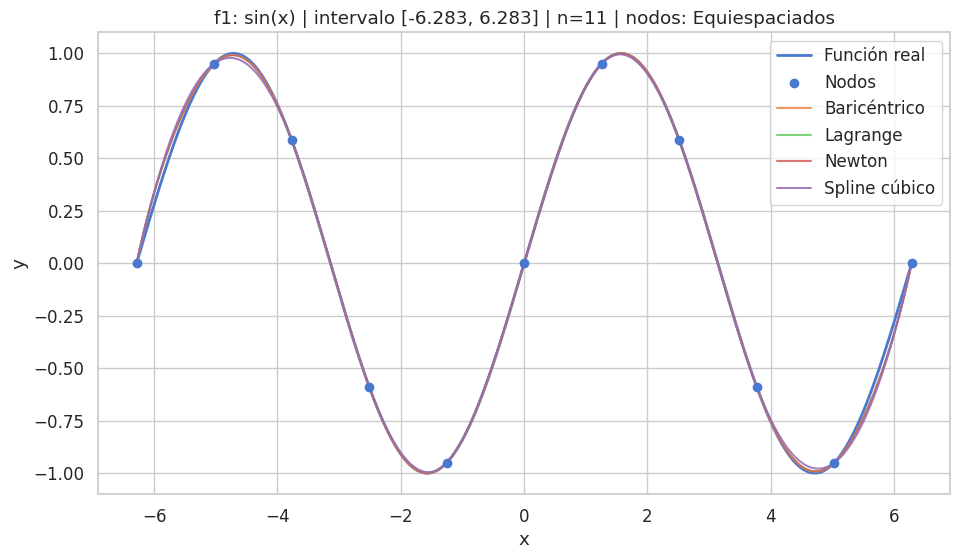

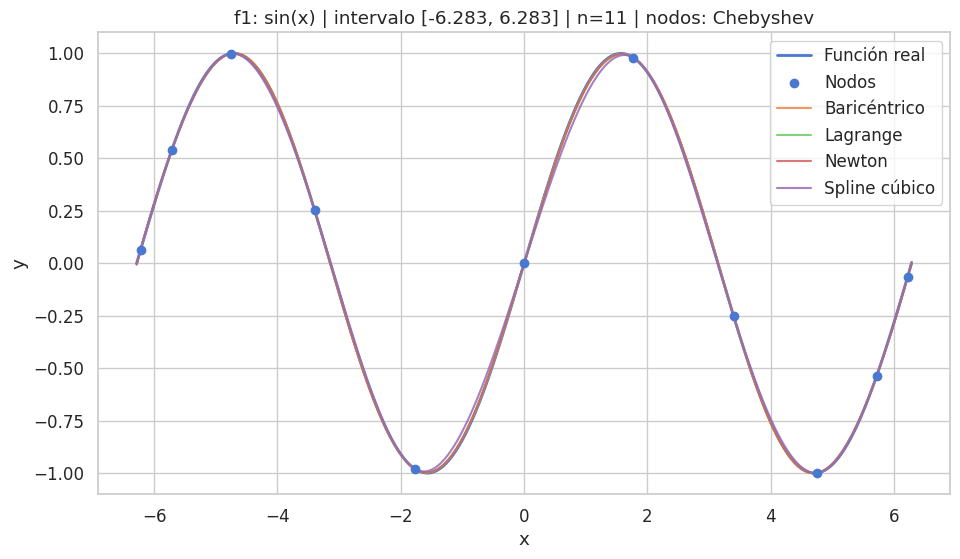

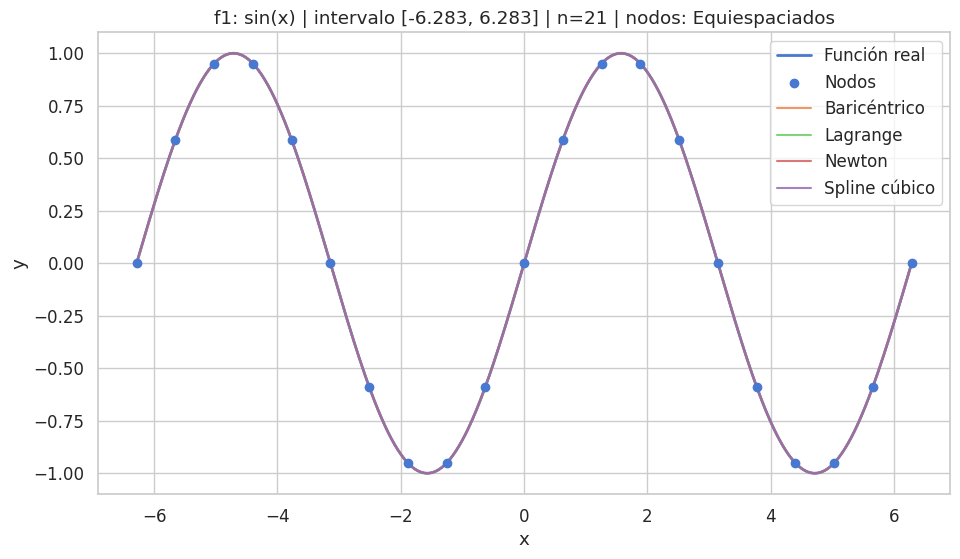

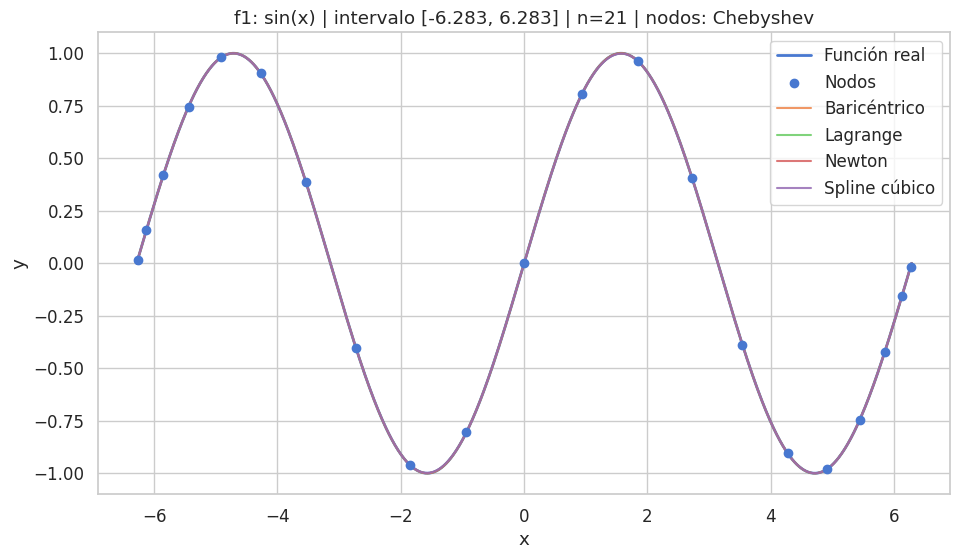

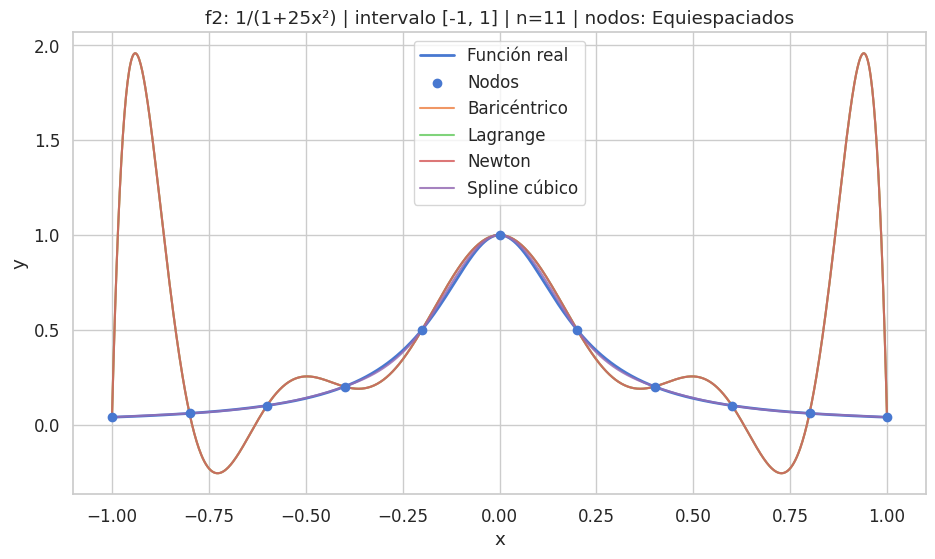

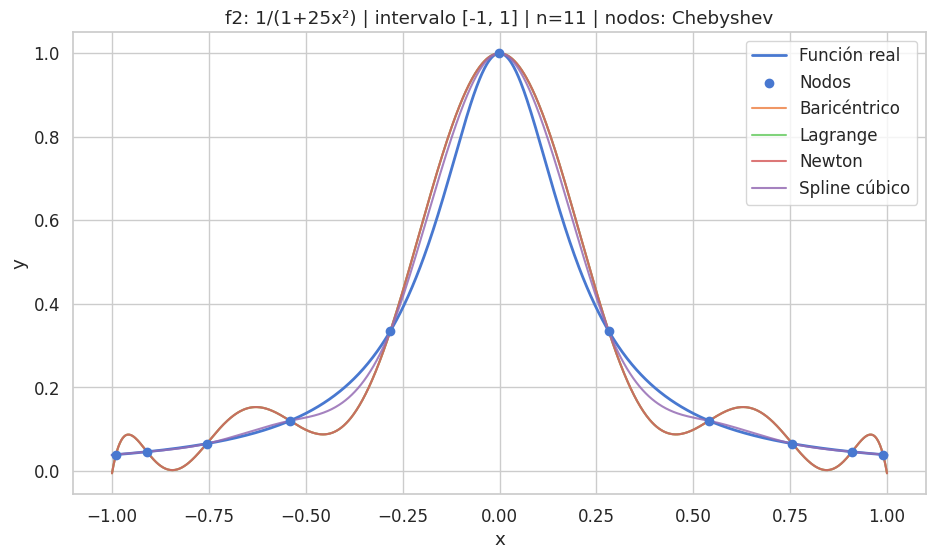

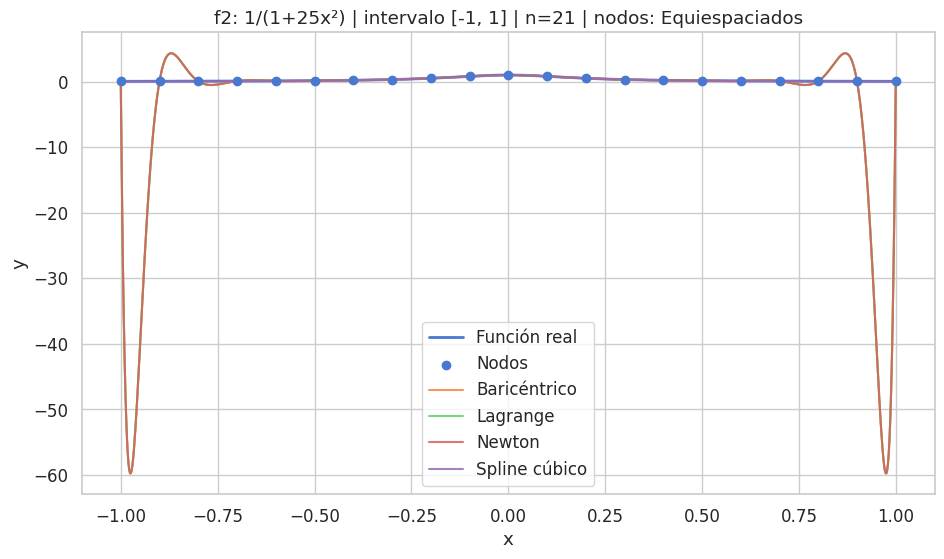

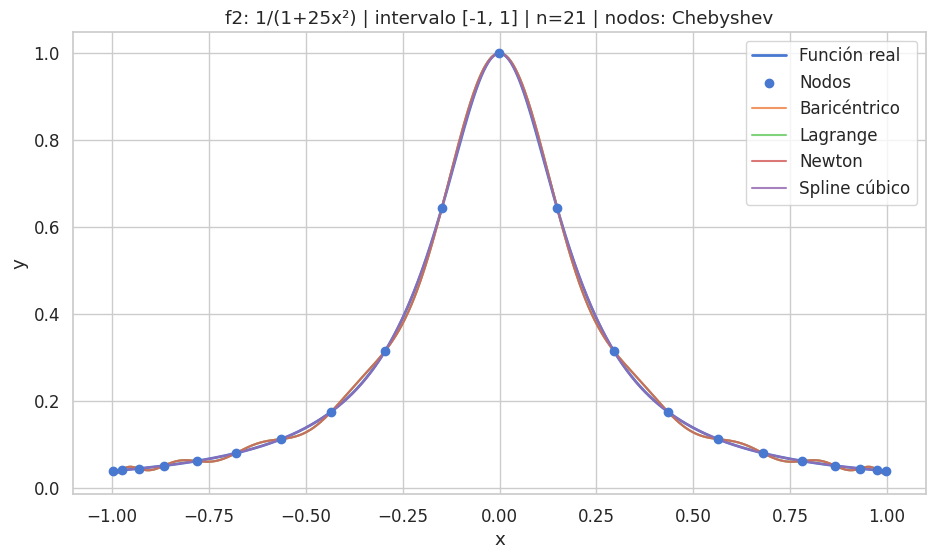

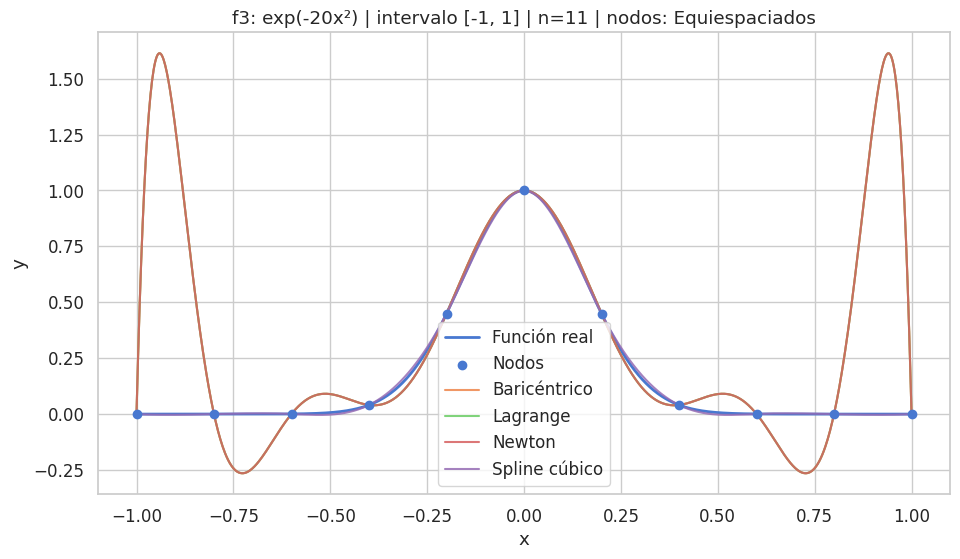

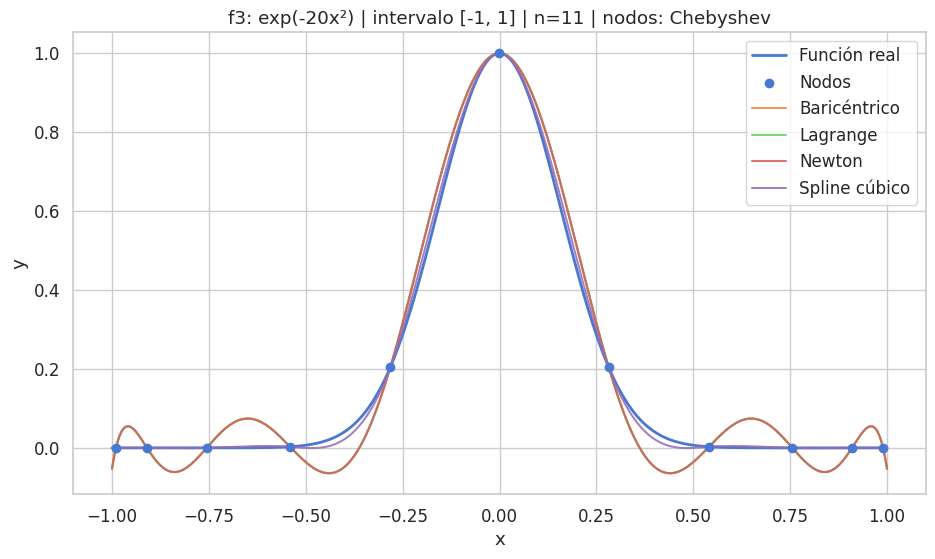

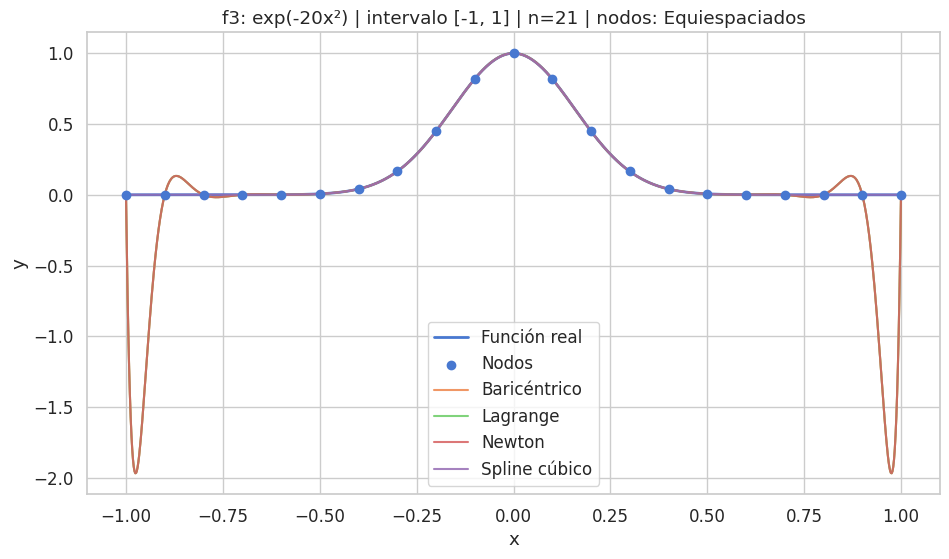

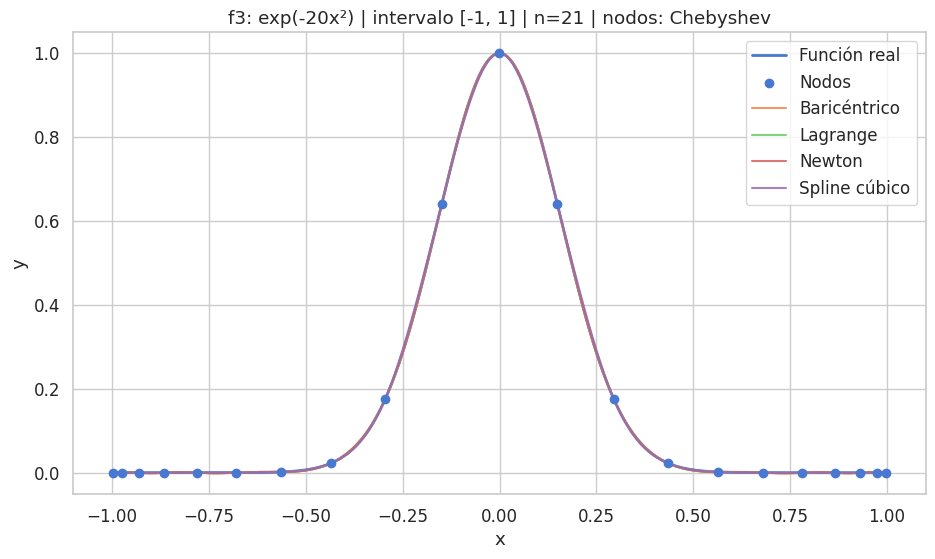

In [65]:
def plot_comparison(function_name, n, node_type):
    spec = function_specs[function_name]
    func = spec["func"]
    a, b = spec["interval"]
    node_builder = node_builders[node_type]

    x_eval = x_eval_by_function[function_name]
    y_real = func(x_eval)
    x_nodes = node_builder(n, a, b)
    y_nodes = func(x_nodes)

    plt.figure(figsize=(11, 6))
    plt.plot(x_eval, y_real, label="Función real", linewidth=2)
    plt.scatter(x_nodes, y_nodes, label="Nodos", zorder=5)

    for method in methods:
        y_interp = predictions[(function_name, n, node_type, method)]["y_interp"]
        plt.plot(x_eval, y_interp, label=method, alpha=0.85)

    plt.title(f"{function_name} | intervalo [{a:.4g}, {b:.4g}] | n={n} | nodos: {node_type}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()


for function_name in function_specs:
    for n in node_counts:
        for node_type in node_builders:
            plot_comparison(function_name, n, node_type)

## 11. Comparación agregada entre nodos equiespaciados y nodos de Chebyshev

Una de las cuestiones principales de la práctica es analizar si la elección de los nodos mejora la calidad de la aproximación.

La siguiente tabla agrupa los errores por tipo de nodo y método. Esta comparación ofrece una primera visión global del comportamiento de los nodos equiespaciados frente a los nodos de Chebyshev.

In [66]:
node_comparison = (
    results_df
    .groupby(["Tipo de nodos", "Método"], as_index=False)
    .agg(
        Error_medio=("Error absoluto máximo", "mean"),
        Error_mediano=("Error absoluto máximo", "median"),
        Tiempo_medio=("Tiempo de construcción (s)", "mean")
    )
    .sort_values(["Método", "Error_medio"])
)

display(node_comparison)

,Tipo de nodos,Método,Error_medio,Error_mediano,Tiempo_medio
0,Chebyshev,Baricéntrico,0.037191,0.011269,0.000256
4,Equiespaciados,Baricéntrico,10.887138,1.764689,0.000291
1,Chebyshev,Lagrange,0.037191,0.011269,0.007201
5,Equiespaciados,Lagrange,10.887139,1.764689,0.006946
2,Chebyshev,Newton,0.037191,0.011269,0.000153
6,Equiespaciados,Newton,10.887138,1.764689,0.000155
7,Equiespaciados,Spline cúbico,0.018710,0.009868,0.000084
3,Chebyshev,Spline cúbico,0.027613,0.018194,0.000079


## 12. Comparaciones relevantes entre tipos de nodos

La comparación agregada anterior resume el comportamiento medio, pero para analizar mejor el efecto de la discretización conviene comparar casos equivalentes: misma función, mismo número de nodos y mismo método, cambiando únicamente el tipo de nodos.

En la siguiente tabla se calcula la razón:

$$
\text{mejora}=\frac{E_{\max,\ \text{equiespaciados}}}{E_{\max,\ \text{Chebyshev}}}
$$

Cuando este valor es mayor que $1$, los nodos de Chebyshev han producido menor error. Cuanto mayor sea la razón, mayor será la mejora conseguida mediante la elección de nodos de Chebyshev.

In [67]:
# Tabla comparativa directa: mismo problema y método, cambiando solo el tipo de nodos.
node_errors = results_df.pivot_table(
    index=["Función", "Nodos", "Método"],
    columns="Tipo de nodos",
    values="Error absoluto máximo"
).reset_index()

node_errors["Mejora Equiespaciados/Chebyshev"] = (
    node_errors["Equiespaciados"] / node_errors["Chebyshev"]
)

node_errors = node_errors.sort_values(
    "Mejora Equiespaciados/Chebyshev",
    ascending=False
)

display(node_errors)

print("Casos donde la elección de nodos de Chebyshev más mejora el error:")
display(node_errors.head(8))

Tipo de nodos,Función,Nodos,Método,Chebyshev,Equiespaciados,Mejora Equiespaciados/Chebyshev
13,f2: 1/(1+25x²),21,Lagrange,1.533338e-02,5.976840e+01,3897.926399
14,f2: 1/(1+25x²),21,Newton,1.533338e-02,5.976840e+01,3897.926188
12,f2: 1/(1+25x²),21,Baricéntrico,1.533338e-02,5.976840e+01,3897.926188
21,f3: exp(-20x²),21,Lagrange,1.385165e-03,1.967518e+00,1420.420902
20,f3: exp(-20x²),21,Baricéntrico,1.385165e-03,1.967517e+00,1420.420514
22,f3: exp(-20x²),21,Newton,1.385165e-03,1.967517e+00,1420.420514
6,f1: sin(x),21,Newton,7.134863e-10,1.812399e-07,254.020111
4,f1: sin(x),21,Baricéntrico,7.134870e-10,1.812400e-07,254.020028
5,f1: sin(x),21,Lagrange,1.465749e-08,1.711420e-06,116.760782
18,f3: exp(-20x²),11,Newton,9.006913e-02,1.613744e+00,17.916730


Casos donde la elección de nodos de Chebyshev más mejora el error:


Tipo de nodos,Función,Nodos,Método,Chebyshev,Equiespaciados,Mejora Equiespaciados/Chebyshev
13,f2: 1/(1+25x²),21,Lagrange,1.533338e-02,5.976840e+01,3897.926399
14,f2: 1/(1+25x²),21,Newton,1.533338e-02,5.976840e+01,3897.926188
12,f2: 1/(1+25x²),21,Baricéntrico,1.533338e-02,5.976840e+01,3897.926188
21,f3: exp(-20x²),21,Lagrange,1.385165e-03,1.967518e+00,1420.420902
20,f3: exp(-20x²),21,Baricéntrico,1.385165e-03,1.967517e+00,1420.420514
22,f3: exp(-20x²),21,Newton,1.385165e-03,1.967517e+00,1420.420514
6,f1: sin(x),21,Newton,7.134863e-10,1.812399e-07,254.020111
4,f1: sin(x),21,Baricéntrico,7.134870e-10,1.812400e-07,254.020028


## 13. Visualización gráfica de la comparación entre nodos

La tabla anterior permite cuantificar el efecto de cambiar únicamente el tipo de nodos. Para facilitar su interpretación, se representan gráficamente las mejoras obtenidas al usar nodos de Chebyshev frente a nodos equiespaciados.

El cociente representado es:

$$
\text{mejora}=\frac{E_{\max,\ \text{equiespaciados}}}{E_{\max,\ \text{Chebyshev}}}
$$

Un valor superior a $1$ indica que los nodos de Chebyshev han reducido el error. Un valor inferior a $1$ indica que, en ese caso concreto, los nodos equiespaciados han producido menor error.

Además, se incluye una gráfica de dispersión en escala logarítmica. En ella, los puntos situados por debajo de la diagonal $y=x$ corresponden a casos en los que el error con Chebyshev es menor que el error con nodos equiespaciados.

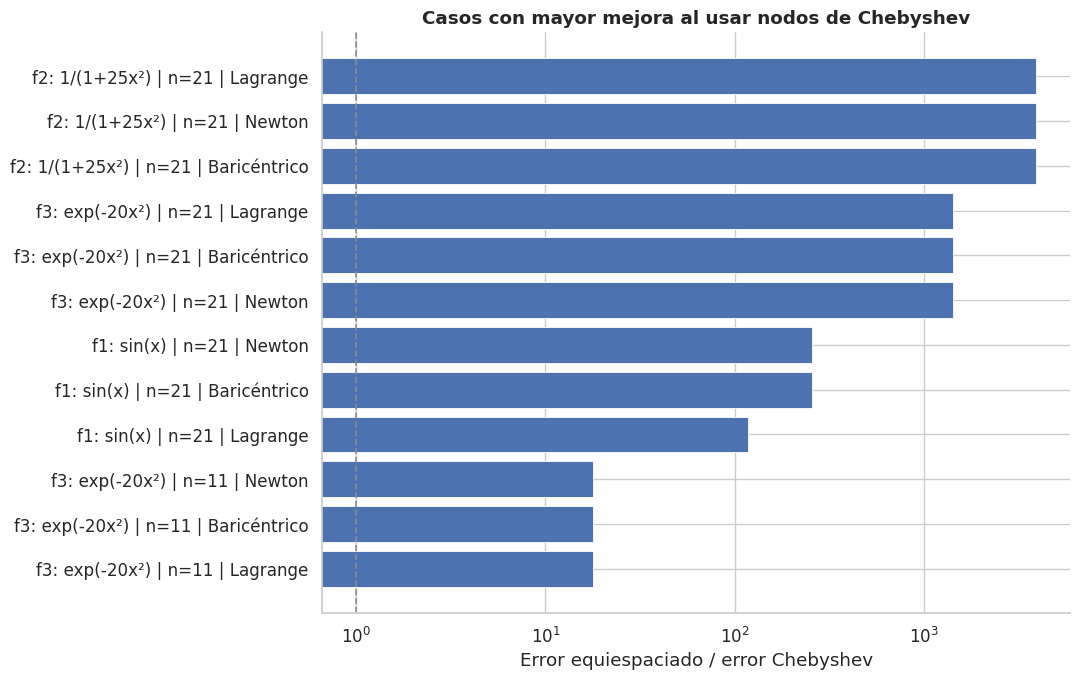

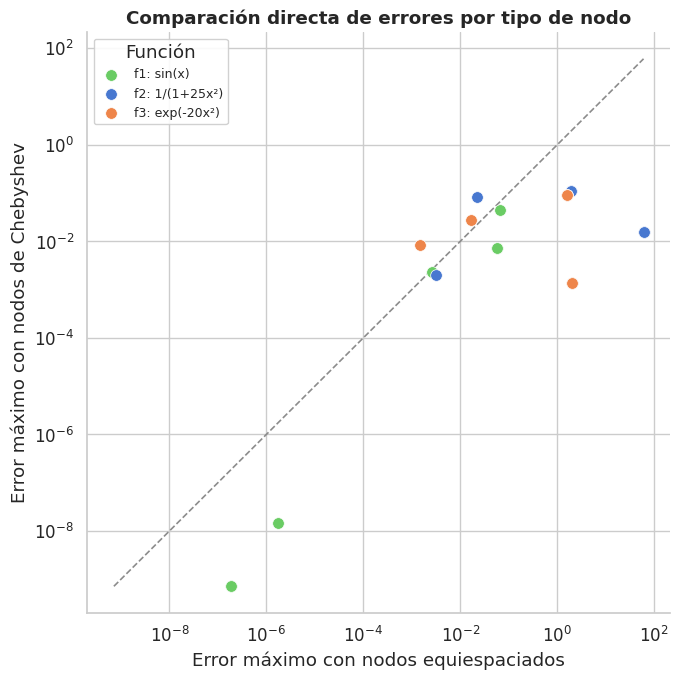

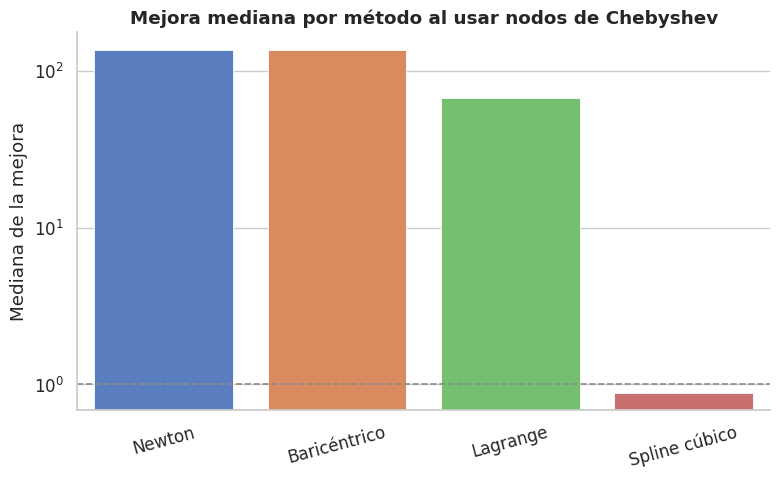

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# ESTILO GENERAL
# =========================================================

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

BLUE = "#4C72B0"
GRAY = "#8C8C8C"

# =========================================================
# DATOS
# =========================================================

plot_data = node_errors[
    np.isfinite(node_errors["Mejora Equiespaciados/Chebyshev"])
].copy()

plot_data = plot_data.sort_values(
    "Mejora Equiespaciados/Chebyshev",
    ascending=False
)

# =========================================================
# GRÁFICA 1
# Casos con mayor mejora usando Chebyshev
# =========================================================

top_plot = plot_data.head(12).copy()

top_plot["Caso"] = (
    top_plot["Función"]
    + " | n=" + top_plot["Nodos"].astype(int).astype(str)
    + " | " + top_plot["Método"]
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    top_plot["Caso"],
    top_plot["Mejora Equiespaciados/Chebyshev"],
    color=BLUE,
    edgecolor="white",
    linewidth=0.6
)

ax.axvline(
    1,
    linestyle="--",
    linewidth=1.2,
    color=GRAY
)

ax.set_xscale("log")

ax.invert_yaxis()

ax.set_xlabel("Error equiespaciado / error Chebyshev")

ax.set_title(
    "Casos con mayor mejora al usar nodos de Chebyshev",
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# =========================================================
# GRÁFICA 2
# Comparación directa de errores
# =========================================================

fig, ax = plt.subplots(figsize=(7, 7))

funciones = plot_data["Función"].unique()

palette = sns.color_palette("muted", len(funciones))

color_map = dict(zip(funciones, palette))

for fname, group in plot_data.groupby("Función"):

    ax.scatter(
        group["Equiespaciados"],
        group["Chebyshev"],
        label=fname,
        color=color_map[fname],
        s=70,
        edgecolors="white",
        linewidths=0.5,
        zorder=3
    )

min_error = min(
    plot_data["Equiespaciados"].min(),
    plot_data["Chebyshev"].min()
)

max_error = max(
    plot_data["Equiespaciados"].max(),
    plot_data["Chebyshev"].max()
)

ax.plot(
    [min_error, max_error],
    [min_error, max_error],
    linestyle="--",
    linewidth=1.2,
    color=GRAY
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Error máximo con nodos equiespaciados")

ax.set_ylabel("Error máximo con nodos de Chebyshev")

ax.set_title(
    "Comparación directa de errores por tipo de nodo",
    fontweight="bold"
)

ax.legend(
    title="Función",
    framealpha=0.9,
    fontsize=9
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# =========================================================
# GRÁFICA 3
# Mejora mediana por método
# =========================================================

method_improvement = (
    plot_data
    .groupby("Método")["Mejora Equiespaciados/Chebyshev"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=method_improvement,
    x="Método",
    y="Mejora Equiespaciados/Chebyshev",
    hue="Método",
    palette="muted",
    legend=False,
    edgecolor="white",
    linewidth=0.6,
    ax=ax
)

ax.axhline(
    1,
    linestyle="--",
    linewidth=1.2,
    color=GRAY
)

ax.set_yscale("log")

ax.set_ylabel("Mediana de la mejora")

ax.set_xlabel("")

ax.set_title(
    "Mejora mediana por método al usar nodos de Chebyshev",
    fontweight="bold"
)

ax.tick_params(axis="x", rotation=15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

##14 Cuadratura de Clenshaw-Curtis

,Función,n,Integral ref.,CC,Error CC,Trapecio,Error trapecio
0,f1: sin(x),11,0.000000,9.020562e-16,9.020562e-16,-1.395147e-16,1.395147e-16
1,f1: sin(x),21,0.000000,2.234107e-15,2.234107e-15,-2.790295e-16,2.790295e-16
2,f2: 1/(1+25x²),11,0.549360,5.652365e-01,1.587617e-02,5.512217e-01,1.861413e-03
3,f2: 1/(1+25x²),21,0.549360,5.496631e-01,3.027553e-04,5.492416e-01,1.186743e-04
4,f3: exp(-20x²),11,0.396333,3.987767e-01,2.443963e-03,3.963362e-01,3.476623e-06
5,f3: exp(-20x²),21,0.396333,3.963345e-01,1.817034e-06,3.963327e-01,1.117058e-10


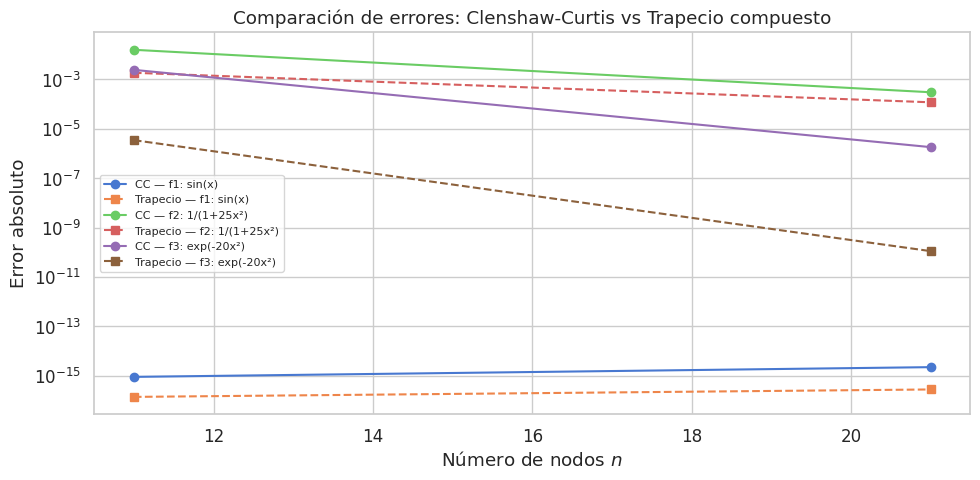

In [69]:
# ─────────────────────────────────────────────────────────────────
# Sección: Extensión — Cuadratura de Clenshaw-Curtis
# ─────────────────────────────────────────────────────────────────

from scipy.integrate import quad

def clenshaw_curtis_weights(n):
    """
    Calcula los pesos de Clenshaw-Curtis para n nodos de Chebyshev
    en el intervalo [-1, 1].
    """
    theta = np.array([(2*k + 1) * np.pi / (2 * n) for k in range(n)])
    x = np.cos(theta)  # nodos de Chebyshev

    weights = np.zeros(n)
    for j in range(n):
        s = 0.0
        for l in range(1, n // 2 + 1):
            b = 2.0 if l < n // 2 else 1.0
            s += b / (4 * l**2 - 1) * np.cos(2 * l * theta[j])
        weights[j] = (1 - s) * 2 / n

    return x, weights


def clenshaw_curtis_integrate(f, a, b, n):
    """
    Integra f en [a, b] usando cuadratura de Clenshaw-Curtis con n nodos.
    Transforma los nodos de Chebyshev desde [-1,1] hasta [a,b].
    """
    x_cheb, w = clenshaw_curtis_weights(n)
    # Transformación al intervalo [a, b]
    x_ab = (a + b) / 2 + (b - a) / 2 * x_cheb
    # Escalar los pesos
    w_ab = w * (b - a) / 2
    return np.dot(w_ab, f(x_ab))


def trapezoid_integrate(f, a, b, n):
    """Regla del trapecio compuesta con n subintervalos."""
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return h * (y[0] / 2 + np.sum(y[1:-1]) + y[-1] / 2)


# ── Experimento ──────────────────────────────────────────────────
node_counts_cc = [11, 21]
cc_results = []

for function_name, spec in function_specs.items():
    func = spec["func"]
    a, b = spec["interval"]

    # Valor de referencia con scipy.integrate.quad
    I_ref, _ = quad(func, a, b)

    for n in node_counts_cc:
        # Clenshaw-Curtis
        I_cc = clenshaw_curtis_integrate(func, a, b, n)
        err_cc = abs(I_cc - I_ref)

        # Trapecio compuesto con el mismo número de puntos
        I_trap = trapezoid_integrate(func, a, b, n - 1)
        err_trap = abs(I_trap - I_ref)

        cc_results.append({
            "Función": function_name,
            "Intervalo": f"[{a:.4g}, {b:.4g}]",
            "n": n,
            "Integral ref.": I_ref,
            "CC": I_cc,
            "Error CC": err_cc,
            "Trapecio": I_trap,
            "Error trapecio": err_trap,
        })

cc_df = pd.DataFrame(cc_results)

# ── Tabla de resultados ──────────────────────────────────────────
display(cc_df[[
    "Función", "n", "Integral ref.", "CC", "Error CC",
    "Trapecio", "Error trapecio"
]])

# ── Gráfica comparativa de errores ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for function_name in function_specs:
    subset = cc_df[cc_df["Función"] == function_name]
    ax.semilogy(subset["n"], subset["Error CC"],
                marker="o", label=f"CC — {function_name}")
    ax.semilogy(subset["n"], subset["Error trapecio"],
                marker="s", linestyle="--",
                label=f"Trapecio — {function_name}")

ax.set_xlabel("Número de nodos $n$")
ax.set_ylabel("Error absoluto")
ax.set_title("Comparación de errores: Clenshaw-Curtis vs Trapecio compuesto")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 15. Conclusiones

A partir de las tablas, las comparaciones específicas y las gráficas, se extraen las siguientes conclusiones:

1. La función $\sin(x)$ se ha estudiado en el intervalo $[-2\pi,2\pi]$, lo que permite observar mejor el comportamiento de los interpoladores que en $[-1,1]$. Aun así, al tratarse de una función suave y periódica, los errores suelen mantenerse controlados con cualquier método y discretización.

2. La función de Runge $\frac{1}{1+25x^2}$ es la que muestra con mayor claridad la importancia de elegir adecuadamente los nodos. Con nodos equiespaciados y polinomios globales aparecen oscilaciones muy pronunciadas cerca de los extremos, que se intensifican al pasar de $n=11$ a $n=21$, llegando a errores del orden de $60$ en los peores casos.

3. Los nodos de Chebyshev mejoran la calidad de la aproximación en los métodos polinómicos globales, especialmente cuando la función presenta cambios bruscos. La tabla de mejoras Equiespaciados/Chebyshev cuantifica este impacto directamente: en algunos casos el error se reduce por factores superiores a $3000$, lo que conecta de forma muy clara la teoría con los resultados experimentales.

4. Los métodos baricéntrico, Lagrange y Newton representan el mismo polinomio interpolador global. Las pequeñas diferencias observadas entre ellos se deben a aspectos numéricos y a la forma en que cada uno construye o evalúa el polinomio, no a diferencias matemáticas de fondo.

5. El método de Newton por diferencias divididas es especialmente útil desde el punto de vista didáctico, porque permite construir el polinomio a partir de una tabla de coeficientes y evaluarlo de forma incremental mediante el esquema de Horner.

6. La interpolación mediante splines cúbicos evita construir un único polinomio de grado alto. Por este motivo ofrece aproximaciones estables por tramos y, en varios experimentos, obtuvo los menores errores absolutos incluso utilizando nodos equiespaciados.

7. Los tiempos de construcción son pequeños en todos los casos dado el tamaño de los problemas. Aun así, la comparación permite observar diferencias de coste entre métodos: Lagrange fue sistemáticamente el más lento, mientras que Newton y spline cúbico presentaron tiempos menores y más uniformes.

8. La extensión a cuadratura numérica refuerza las conclusiones anteriores desde otra perspectiva. La cuadratura de Clenshaw-Curtis, que hereda los nodos de Chebyshev, es ventajosa para funciones suaves definidas globalmente en el intervalo. Sin embargo, para $f_3(x)=e^{-20x^2}$, cuya variación se concentra en una región pequeña alrededor del origen, el trapecio compuesto resultó más preciso porque sus nodos equiespaciados muestrean mejor esa zona. Este resultado muestra que la elección del método de cuadratura, al igual que la del interpolador, depende del comportamiento de la función a integrar.

La lectura conjunta de las tablas y las gráficas confirma que la elección de los nodos no es un detalle secundario. En interpolación polinómica global, cambiar de nodos equiespaciados a nodos de Chebyshev puede reducir el error de forma muy notable, especialmente en funciones donde aparecen oscilaciones cerca de los extremos. Esta misma lógica se extiende a la integración numérica, donde la distribución de los puntos de evaluación respecto a la geometría de la función determina en gran medida la precisión obtenida.